# MCMC demos

ここからは **`jeanspy/model_numpyro.py`** のデモです（テスト `test_model_numpyro.py` と同様の内容を、ノートブックで可視化しながら実行）。


In [1]:
import numpyro
import jax
import jax.random
import jax.numpy as jnp
import numpy as np
import numpyro.distributions as dist
import xarray as xr
from numpyro.infer import AIES, MCMC, NUTS
import matplotlib.pyplot as plt
import jeanspy
import jeanspy.model_numpyro as model_numpyro
from jeanspy.model_numpyro import ConstantAnisotropyModel, DSphModel, NFWModel, PlummerModel



def concat_datatrees_draw(left, right):
    group_names = sorted(set(left.children) | set(right.children))
    tree_mapping = {}
    for group_name in group_names:
        left_dataset = left.children[group_name].dataset
        right_dataset = right.children[group_name].dataset
        if "draw" in left_dataset.dims or "draw" in right_dataset.dims:
            combined = xr.concat(
                [left_dataset, right_dataset],
                dim="draw",
                data_vars="all",
                coords="minimal",
                compat="override",
                combine_attrs="override",
            )
            combined = combined.assign_coords(draw=np.arange(combined.sizes["draw"], dtype=np.int64))
        else:
            if not left_dataset.equals(right_dataset):
                raise ValueError(f"Static DataTree group changed unexpectedly: {group_name}")
            combined = left_dataset
        tree_mapping[group_name] = combined
    return xr.DataTree.from_dict(tree_mapping)



# For ensemble samplers
numpyro.set_host_device_count(16)


key = jax.random.PRNGKey(123)


print(jax.devices())


/home/gomesu/workspace/dev_jeanspy/jeanspy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[CudaDevice(id=0)]


# Plummer: `re_pc` 推定（NUTS + AIES）

Mockデータ（$R$ のサンプル）を表示し、NUTSとAIESの両方で推定します。

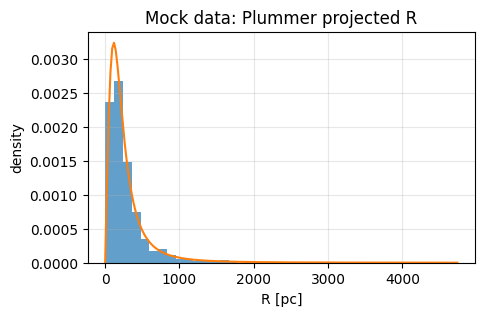

In [2]:
import matplotlib.pyplot as plt

key, subkey = jax.random.split(key)
true_re = 200.0
n = 1024
model_true = PlummerModel()
R_obs = jnp.array(model_true.sample_R(subkey, n, re_pc=true_re))

plt.figure(figsize=(5, 3))
plt.hist(R_obs, bins=40, density=True, alpha=0.7)
plt.title("Mock data: Plummer projected R")
plt.xlabel("R [pc]")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
# plot true density
R_grid = jnp.linspace(0, jnp.max(R_obs), 200)
log_pdf_true = jnp.array(model_true.log_prob_R(R_grid, re_pc=true_re))
plt.plot(R_grid, jnp.exp(log_pdf_true), label=f"true PDF, re_pc={true_re} pc")
plt.show()

# How to define a model in NumPyro: 
# 1. sample parameters using numpyro.sample, and transform as needed.
# 2. compute log-likelihood
# 3. add it via numpyro.factor
def plummer_model(R_pc):
    # Declare parameters
    log_re = numpyro.sample("log_re", dist.Normal(jnp.log(200.0), 0.8))
    # Optional: transform to physical space for better interpretability and/or to impose constraints.
    re_pc = jnp.exp(log_re)
    numpyro.deterministic("re_pc", re_pc)  # store the transformed parameter for later inspection
    # Compute log-likelihood and add it to the model.
    logp = PlummerModel().log_prob_R(jnp.asarray(R_pc), re_pc=re_pc).sum()
    numpyro.factor("lik", logp)  # monitor the log-likelihood as a factor in the model

    

## NUTS

/tmp/ipykernel_428618/2301113819.py:6: UserWarning: There are not enough devices to run parallel chains: expected 8 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(8)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_pl_nuts = MCMC(nuts, num_warmup=300, num_samples=300, num_chains=8, progress_bar=True)
sample: 100%|██████████| 600/600 [00:00<00:00, 651.39it/s, 1 steps of size 9.05e-01. acc. prob=0.95] 


        mean   sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
re_pc  194.6  5.3      190      200       722       865  1.01      0.19   

      mcse_sd  
re_pc    0.14  


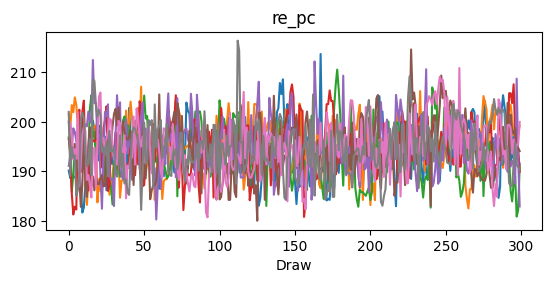

In [3]:
# NUTS
import arviz as az
key, subkey = jax.random.split(key)

nuts = NUTS(plummer_model)
mcmc_pl_nuts = MCMC(nuts, num_warmup=300, num_samples=300, num_chains=8, progress_bar=True)
mcmc_pl_nuts.run(subkey, R_pc=R_obs)

idata_pl_nuts = az.from_numpyro(mcmc_pl_nuts)
print(az.summary(idata_pl_nuts, var_names=["re_pc"]))
az.plot_trace(idata_pl_nuts, var_names=["re_pc"])
plt.show()

## AIES

warmup: 100%|██████████| 200/200 [00:02<00:00, 71.56it/s, acc. prob=0.41] 


Chain will start from last_state of warmup, iteration 1/5
EnsembleSamplerState(z={'log_re': Array([5.2503147, 5.2768826, 5.2495785, 5.275198 , 5.26923  , 5.2461   ,
       5.234123 , 5.314911 , 5.264348 , 5.287333 , 5.250709 , 5.2772484,
       5.2563915, 5.2840014, 5.2337294, 5.27112  ], dtype=float32)}, inner_state=AIESState(i=Array(200., dtype=float32, weak_type=True), accept_prob=Array(0.375, dtype=float32), mean_accept_prob=Array(0.41387376, dtype=float32), rng_key=Array([1454385748,  152645212], dtype=uint32)), rng_key=Array([ 585229124, 3810146438], dtype=uint32))


sample: 100%|██████████| 200/200 [00:00<00:00, 1866.94it/s, acc. prob=0.42]

Chain 1 idata:


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 16, draw: 200)
│       Coordinates:
│         * chain    (chain) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
│         * draw     (draw) int64 2kB 0 1 2 3 4 5 6 7 ... 193 194 195 196 197 198 199
│       Data variables:
│           log_re   (chain, draw) float32 13kB 5.25 5.25 5.25 5.25 ... 5.29 5.283 5.283
│           re_pc    (chain, draw) float32 13kB 190.6 190.6 190.6 ... 198.3 196.9 196.9
│       Attributes:
│           created_at:                 2026-03-11T06:08:42.900185+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /sample_stats
│       Attributes:
│           created_at:                 2026-03-11T06:08:42.901864+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /observed_data
        Dimensions:    (lik_dim_0: 0)
        Coordinates:
          * lik_dim_0  (lik_dim_0) int64 0B 
        Data variables:
            lik        (lik_dim_0) float32 0B ...
        Attributes:
            created_at:                 2026-03-11T06:08:42.903004+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

...

sample: 100%|██████████| 200/200 [00:00<00:00, 1851.96it/s, acc. prob=0.43]

Chain 5 idata:


<xarray.DataTree>
Group: /
├── Group: /observed_data
│       Dimensions:    (lik_dim_0: 0)
│       Coordinates:
│         * lik_dim_0  (lik_dim_0) int64 0B 
│       Data variables:
│           lik        (lik_dim_0) float32 0B ...
│       Attributes:
│           created_at:                 2026-03-11T06:08:42.903004+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /posterior
│       Dimensions:  (chain: 16, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           log_re   (chain, draw) float32 64kB 5.25 5.25 5.25 ... 5.254 5.284 5.227
│           re_pc    (chain, draw) float32 64kB 190.6 190.6 190.6 ... 191.3 197.2 186.2
│       Attributes:
│           created_at:                 2026-03-11T06:08:42.900185+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /sample_stats
        Attributes:
            created_at:                 2026-03-11T06:08:42.901864+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

Concatenated idata:


<xarray.DataTree>
Group: /
├── Group: /observed_data
│       Dimensions:    (lik_dim_0: 0)
│       Coordinates:
│         * lik_dim_0  (lik_dim_0) int64 0B 
│       Data variables:
│           lik        (lik_dim_0) float32 0B ...
│       Attributes:
│           created_at:                 2026-03-11T06:08:42.903004+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /posterior
│       Dimensions:  (chain: 16, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           log_re   (chain, draw) float32 64kB 5.25 5.25 5.25 ... 5.254 5.284 5.227
│           re_pc    (chain, draw) float32 64kB 190.6 190.6 190.6 ... 191.3 197.2 186.2
│       Attributes:
│           created_at:                 2026-03-11T06:08:42.900185+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /sample_stats
        Attributes:
            created_at:                 2026-03-11T06:08:42.901864+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

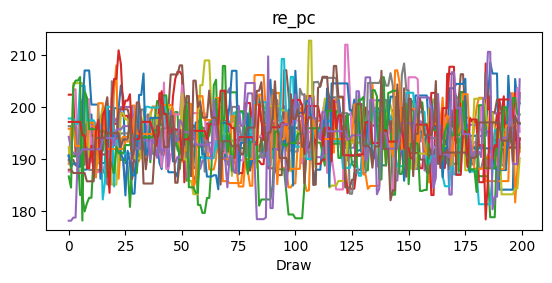

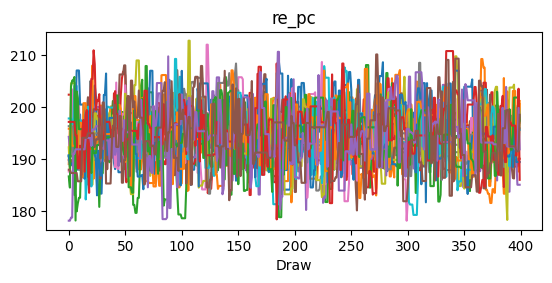

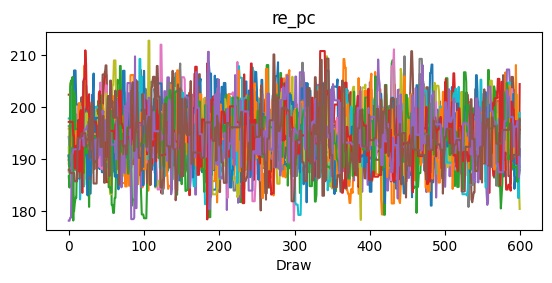

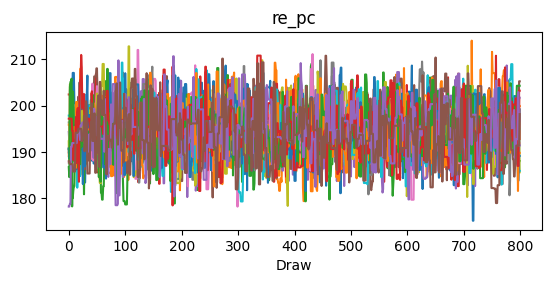

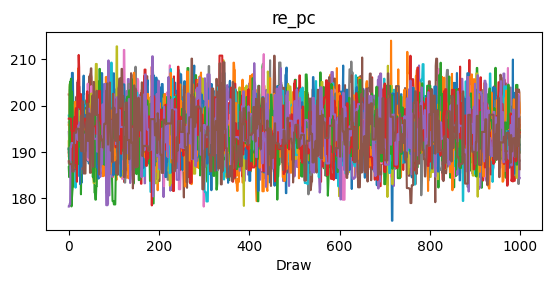

In [4]:
# AIES (gradient-free)
key, subkey = jax.random.split(key)
num_chains = 16
keys = jax.random.split(subkey, num_chains)



sampler = AIES(plummer_model)
mcmc_pl_aies = MCMC(
    sampler,
    num_warmup=200,
    num_samples=200,
    num_chains=num_chains,
    chain_method="vectorized",
    progress_bar=True,
)
# mcmc_pl_aies.run(keys, R_pc=R_obs)
mcmc_pl_aies.warmup(keys, R_pc=R_obs)
last_state = mcmc_pl_aies.last_state
idata_list = []
idata_concat = None

for i in range(5):
    mcmc_pl_aies.post_warmup_state = mcmc_pl_aies.last_state
    print(f"Chain will start from last_state of warmup, iteration {i+1}/5")
    print(mcmc_pl_aies.post_warmup_state)
    mcmc_pl_aies.run(keys, R_pc=R_obs)
    idata = az.from_numpyro(mcmc_pl_aies)
    print(f"Chain {i+1} idata:")
    idata_list.append(idata)
    if idata_concat is None:
        idata_concat = idata
    else:
        idata_concat = concat_datatrees_draw(idata_concat, idata)
    display(idata_concat)
    az.plot_trace(idata_concat, var_names=["re_pc"])

print("Concatenated idata:")

display(idata_concat)


idata_pl_aies = idata_concat

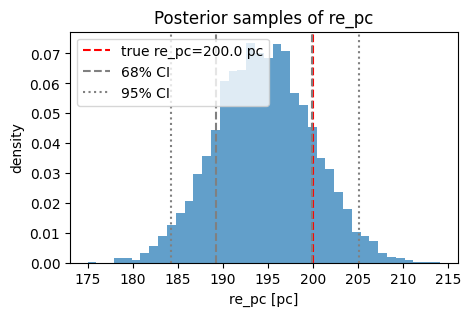

In [5]:
# plot posterior samples
re_samples = idata_concat.posterior["re_pc"].values.flatten()
plt.figure(figsize=(5, 3))
plt.hist(re_samples, bins=40, density=True, alpha=0.7)
# plot true value as red vertical line
plt.axvline(true_re, color="red", linestyle="--", label=f"true re_pc={true_re} pc")
# plot 68%/95% credible intervals as vertical lines
ci_68 = jnp.percentile(re_samples, jnp.array([16, 84]))
ci_95 = jnp.percentile(re_samples, jnp.array([2.5, 97.5]))
plt.axvline(ci_68[0], color="gray", linestyle="--", label="68% CI")
plt.axvline(ci_68[1], color="gray", linestyle="--")
plt.axvline(ci_95[0], color="gray", linestyle=":", label="95% CI")
plt.axvline(ci_95[1], color="gray", linestyle=":")
plt.title("Posterior samples of re_pc")
plt.xlabel("re_pc [pc]")
plt.ylabel("density")
plt.legend()
plt.show()

# Jeans demo: Plummer + NFW + constant anisotropy

Mockデータ（$R$ と $v_{los}$）を生成し、AIESで **全パラメータ**（`re_pc, rs_pc, rhos_Msunpc3, r_t_pc, beta_ani, vmem_kms`）の事後分布を推定します。

JAX devices:
1


[CudaDevice(id=0)]

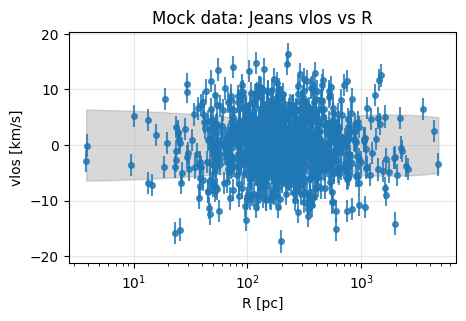

In [6]:
import os
# Tell JAX to avoid the GPU memory allocation in advance but allocate memory as needed
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=2"  # Virtually divide the CPU device into 2 to allow parallel chains on GPU
import numpyro
numpyro.set_host_device_count(2)  # same effect as the above XLA_FLAGS for num_chains=2, but it does not work.... Why?
import jax.random
import jax.numpy as jnp
from numpyro.infer import AIES, MCMC, NUTS
import numpyro.distributions as dist
# Check available JAX devices
print("JAX devices:")
print(jax.local_device_count())
display(jax.devices())
import matplotlib.pyplot as plt
import jeanspy
import jeanspy.model_numpyro
from jeanspy.model_numpyro import ConstantAnisotropyModel, DSphModel, NFWModel, PlummerModel


key = jax.random.PRNGKey(123)

key, subkey = jax.random.split(key)

true = {
    "re_pc": 200.0,
    "rs_pc": 1200.0,
    "rhos_Msunpc3": 1e-2,
    "r_t_pc": 8000.0,
    "beta_ani": 0.2,
    "vmem_kms": 0.0,
}

stellar = PlummerModel()
dm = NFWModel()
ani = ConstantAnisotropyModel()
dsph = DSphModel(submodels={"StellarModel": stellar, "DMModel": dm, "AnisotropyModel": ani})

@jax.jit
def sigmalos2(R_pc, params):
    return dsph.sigmalos2(R_pc, params=params, n_u=192, u_max=1500.0)

nR = 1000
R_pc = stellar.sample_R(subkey, nR, re_pc=true["re_pc"])
err = 2.0
err2 = (err * jnp.ones_like(R_pc)) ** 2

s2_true = sigmalos2(R_pc, params=true)
key, subkey = jax.random.split(key)
vlos = true["vmem_kms"] + jnp.sqrt(s2_true + err2) * jax.random.normal(subkey, shape=R_pc.shape)

R_obs = jnp.array(R_pc)
v_obs = jnp.array(vlos)
e_obs = jnp.array(err * jnp.ones_like(R_obs))
v_obs_min = jnp.min(v_obs)
v_obs_max = jnp.max(v_obs)

# Mock data display
plt.figure(figsize=(5, 3))
plt.errorbar(R_obs, v_obs, yerr=e_obs, fmt="o", ms=4, alpha=0.8)
plt.xscale("log")
plt.title("Mock data: Jeans vlos vs R")
plt.xlabel("R [pc]")
plt.ylabel("vlos [km/s]")
plt.grid(True, alpha=0.3)
# plt.show()

# Velocity dispersion proifile (Mock & exact) display
# plt.figure(figsize=(5, 3))
_R_obs = jnp.logspace(jnp.log10(jnp.min(R_obs)), jnp.log10(jnp.max(R_obs)), 200)
_sig = sigmalos2(_R_obs, params=true)
_sig = jnp.sqrt(_sig)
# plt.plot(_R_obs,_sig)
plt.fill_between(_R_obs,-_sig,+_sig, alpha=0.3, label="true sigmalos", color="gray")
plt.xscale("log")
plt.xlabel("R [pc]")
plt.ylabel("vlos [km/s]")
plt.grid(True, alpha=0.3)
plt.show()

def jeans_model(R_pc, vlos_kms, e_vlos_kms):
    # log_re = numpyro.sample("log_re", dist.Normal(jnp.log(200.0), 0.8))
    log_re = jnp.log10(200)  # deterministic for testing
    log_rs = numpyro.sample("log_rs", dist.Uniform(0.0,5.0))
    log_rhos = numpyro.sample("log_rhos", dist.Uniform(-5.0, 0.0))
    log_r_t = numpyro.sample("log_r_t", dist.Uniform(0.0,5.0))
    log10_1_minus_beta_ani = numpyro.sample("log10_1_minus_beta_ani", dist.Uniform(-1.0, 1.0))
    beta_ani = 1.0 - 10**log10_1_minus_beta_ani
    numpyro.deterministic("beta_ani", beta_ani)
    # beta_ani = numpyro.sample("beta_ani", dist.Uniform(-0.5, 0.8))
    vmem_kms = numpyro.sample("vmem_kms", dist.Uniform(v_obs_min, v_obs_max))

    re_pc = 10**log_re
    rs_pc = 10**log_rs
    rhos_Msunpc3 = 10**log_rhos
    r_t_pc = 10**log_r_t

    params = {
        "re_pc": re_pc,
        "rs_pc": rs_pc,
        "rhos_Msunpc3": rhos_Msunpc3,
        "r_t_pc": r_t_pc,
        "beta_ani": beta_ani,
        "vmem_kms": vmem_kms,
    }

    s2 = sigmalos2(jnp.asarray(R_pc), params=params)
    s2 = jnp.clip(s2, min=1e-12, max=1e12)
    scale = jnp.sqrt(s2 + jnp.asarray(e_vlos_kms) ** 2)
    numpyro.sample("vlos", dist.Normal(vmem_kms, scale), obs=jnp.asarray(vlos_kms))

    numpyro.deterministic("re_pc", re_pc)
    numpyro.deterministic("rs_pc", rs_pc)
    numpyro.deterministic("rhos_Msunpc3", rhos_Msunpc3)
    numpyro.deterministic("r_t_pc", r_t_pc)
    # numpyro.deterministic("beta_ani", beta_ani)
    # numpyro.deterministic("vmem_kms", vmem_kms)

## AIES

In [7]:
# check jax can use GPU

import tqdm 

import arviz as az



display(jax.devices())



# AIES on Jeans model (all params)



key, subkey = jax.random.split(key)

num_chains = 32

keys = jax.random.split(subkey, num_chains)

epochs = 20

num_warmup = 1000

num_samples = 100



sampler = AIES(

    model=jeans_model,

    moves={

        AIES.StretchMove(): 0.8,  # NOTE: numpyro default is DEMove

        AIES.DEMove(): 0.2,

    },

    init_strategy=numpyro.infer.init_to_sample  # NOTE: numpyro default is init_to_uniform

)



mcmc_jeans = MCMC(

    sampler,

    num_warmup=num_warmup,

    num_samples=num_samples,

    num_chains=num_chains,

    chain_method="vectorized",  # EnsembleSamplers in numpyro only support "vectorized" for now

    progress_bar=False,

    jit_model_args=True

)

idata_jeans = None

with tqdm.tqdm(total=epochs) as pbar:

    for epoch in range(epochs):

        if epoch == 0:

            assert mcmc_jeans.post_warmup_state is None, "post_warmup_state should be None before warmup. Please check the code."

            assert mcmc_jeans.last_state is None, "last_state should be None before warmup. Please check the code."

        else:

            assert mcmc_jeans.last_state is not None, "last_state should not be None after warmup. Please check the code."

        mcmc_jeans.post_warmup_state = mcmc_jeans.last_state

        mcmc_jeans.run(keys, R_pc=R_obs, vlos_kms=v_obs, e_vlos_kms=e_obs)

        if idata_jeans is None:

            idata_jeans = az.from_numpyro(mcmc_jeans)

        else:

            idata_jeans_new = az.from_numpyro(mcmc_jeans)

            idata_jeans = concat_datatrees_draw(idata_jeans, idata_jeans_new)

        idata_jeans.to_netcdf("jeans_aies_dict.nc")

        pbar.set_description(f"Epoch {epoch+1}/{epochs}")

        pbar.update(1)

idata_jeans


[CudaDevice(id=0)]

Epoch 20/20: 100%|██████████| 20/20 [01:50<00:00,  5.54s/it]


<xarray.DataTree>
Group: /
├── Group: /observed_data
│       Dimensions:     (vlos_dim_0: 1000)
│       Coordinates:
│         * vlos_dim_0  (vlos_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           vlos        (vlos_dim_0) float32 4kB ...
│       Attributes:
│           created_at:                 2026-03-11T06:09:03.228752+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /posterior
│       Dimensions:                 (chain: 32, draw: 2000)
│       Coordinates:
│         * chain                   (chain) int64 256B 0 1 2 3 4 5 ... 26 27 28 29 30 31
│         * draw                    (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables:
│           beta_ani                (chain, draw) float32 256kB 0.1788 0.1818 ... 0.1446
│           log10_1_minus_beta_ani  (chain, draw) float32 256kB -0.08557 ... -0.06784
│           log_r_t                 (chain, draw) float32 256kB 4.579 4.679 ... 3.347
│           log_rhos                (chain, draw) float32 256kB -1.632 -1.563 ... -1.881
│           log_rs                  (chain, draw) float32 256kB 2.835 2.779 ... 3.018
│           r_t_pc                  (chain, draw) float32 256kB 3.789e+04 ... 2.223e+03
│           re_pc                   (chain, draw) float32 256kB 200.0 200.0 ... 200.0
│           rhos_Msunpc3            (chain, draw) float32 256kB 0.02333 ... 0.01315
│           rs_pc                   (chain, draw) float32 256kB 684.2 ... 1.043e+03
│           vmem_kms                (chain, draw) float32 256kB 0.01025 ... 0.2874
│       Attributes:
│           created_at:                 2026-03-11T06:09:03.225928+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /sample_stats
        Attributes:
            created_at:                 2026-03-11T06:09:03.227947+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

In [8]:
import arviz as az
idata = az.from_numpyro(mcmc_jeans)

In [9]:
# When we substitute the `last_state` of MCMC instance into `post_warmup_state`, 
# it will skip the warmup phase and directly start sampling from the last state of warmup. 
# This allows us to continue sampling from where we left off, 
# which can be useful for extending the number of samples or for running additional chains 
# without having to redo the warmup phase.

################# Example ##################

#mcmc_jeans.post_warmup_state = mcmc_jeans.last_state
#mcmc_jeans.run(keys, R_pc=R_obs, vlos_kms=v_obs, e_vlos_kms=e_obs)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
rs_pc,5e+03,1e+04,150,33000,50,35,1.68,1800,2700
rhos_Msunpc3,0.07,0.2,0.0014,0.41,53,38,1.60,0.034,0.068
r_t_pc,2e+04,2e+04,48,70000,70,36,1.38,1700,1700
beta_ani,-0.7,2,-8.9,0.42,55,34,1.56,0.4,0.62
vmem_kms,0.2,0.3,-0.11,0.64,82,70,1.30,0.051,0.13


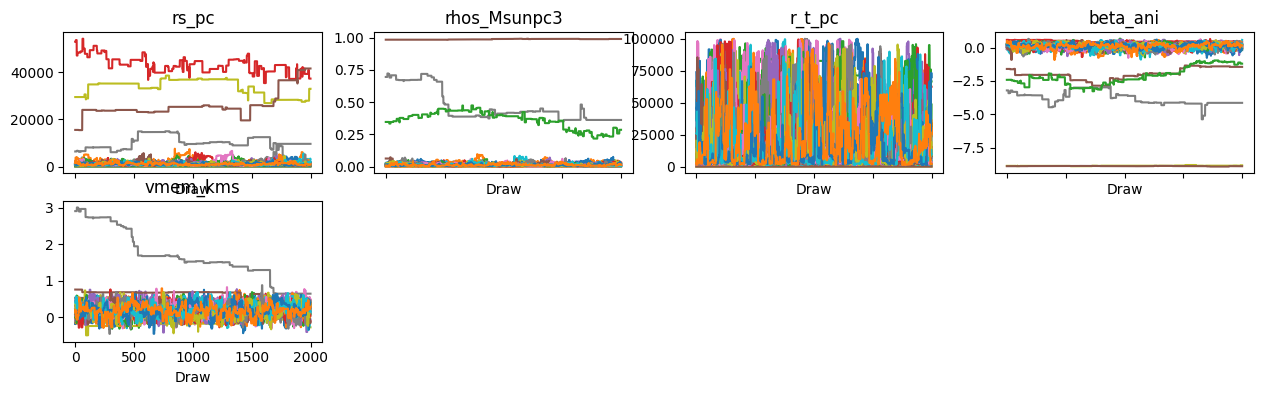

In [10]:
# idata_jeans = az.from_numpyro(mcmc_jeans)
var_names = ["rs_pc", "rhos_Msunpc3", "r_t_pc", "beta_ani", "vmem_kms"]
display(az.summary(idata_jeans, var_names=var_names))
az.plot_trace(idata_jeans, var_names=var_names)
plt.show()

In [11]:
if hasattr(idata, "log_likelihood"):

    loglik = idata.log_likelihood["vlos"].sum(dim="vlos_dim_0")

    plt.plot(loglik.T)

    plt.ylim(bottom=-3130, top=float(loglik.max()))

    plt.show()

else:

    print("log_likelihood group is not present in this DataTree; skipping log-likelihood trace plot.")


log_likelihood group is not present in this DataTree; skipping log-likelihood trace plot.


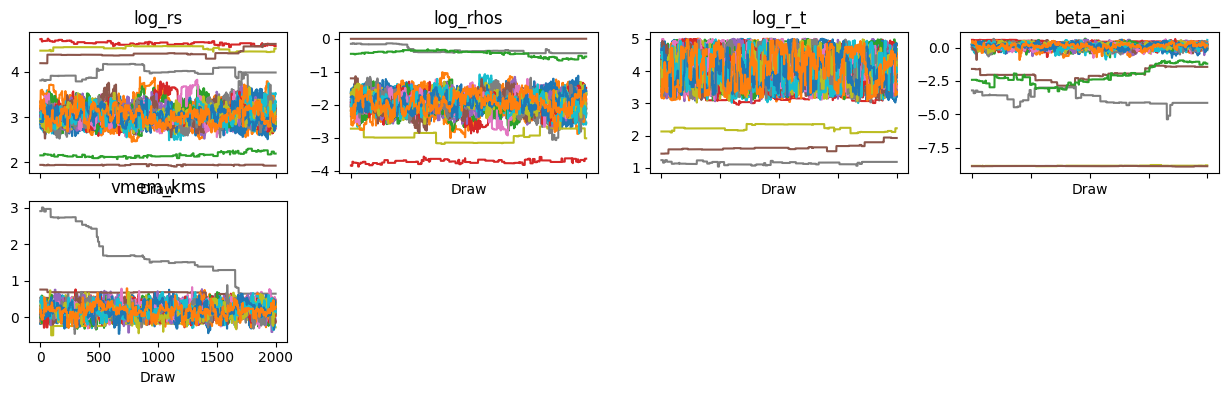

In [12]:
log_var_names = ["log_rs", "log_rhos", "log_r_t", "beta_ani", "vmem_kms"]
try:
    az.plot_trace(idata_jeans, var_names=log_var_names); plt.show()
except Exception as e:
    print(f"Error plotting trace: {e}")


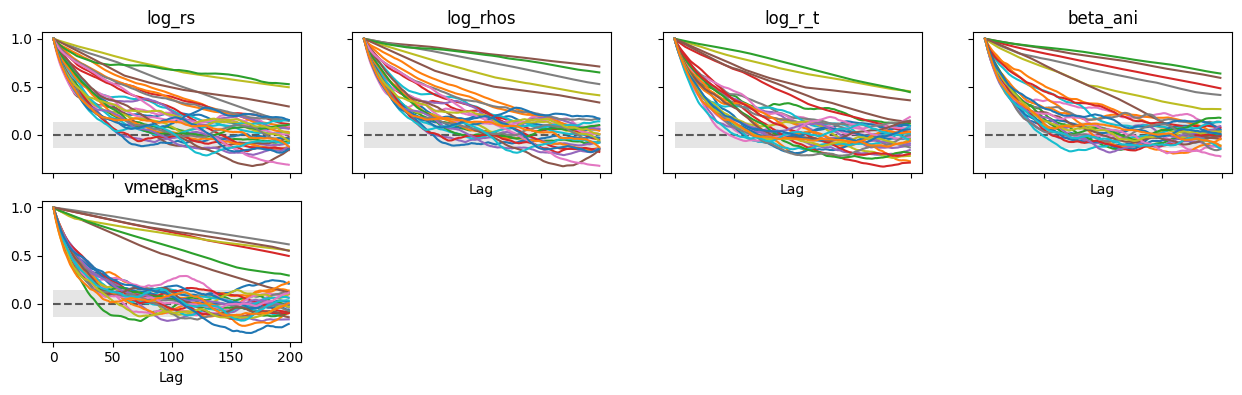

In [13]:
az.plot_autocorr(idata_jeans,var_names=log_var_names,max_lag=200)
plt.show()

In [14]:
# plot rhat
log_var_names = ["log_rs", "log_rhos", "log_r_t", "beta_ani", "vmem_kms"]
rhat = az.rhat(idata_jeans, var_names=log_var_names)
display(rhat)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:   ()
    Data variables:
        log_rs    float64 8B 1.685
        log_rhos  float64 8B 1.596
        log_r_t   float64 8B 1.377
        beta_ani  float64 8B 1.557
        vmem_kms  float64 8B 1.299

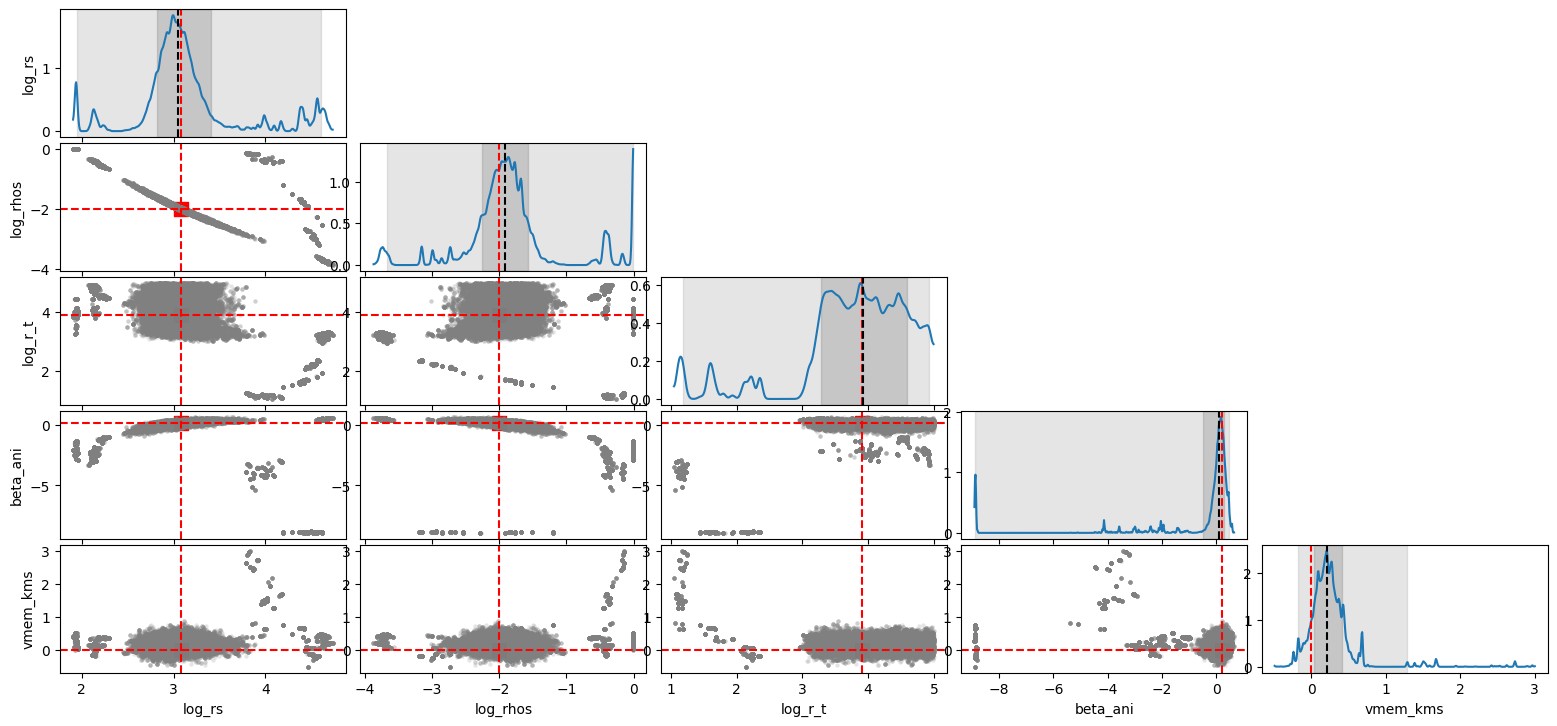

<xarray.DataTree>
Group: /
├── Group: /observed_data
│       Dimensions:     (vlos_dim_0: 1000)
│       Coordinates:
│         * vlos_dim_0  (vlos_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           vlos        (vlos_dim_0) float32 4kB ...
│       Attributes:
│           created_at:                 2026-03-11T06:09:03.228752+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /posterior
│       Dimensions:                 (chain: 32, draw: 2000)
│       Coordinates:
│         * chain                   (chain) int64 256B 0 1 2 3 4 5 ... 26 27 28 29 30 31
│         * draw                    (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables:
│           beta_ani                (chain, draw) float32 256kB 0.1788 0.1818 ... 0.1446
│           log10_1_minus_beta_ani  (chain, draw) float32 256kB -0.08557 ... -0.06784
│           log_r_t                 (chain, draw) float32 256kB 4.579 4.679 ... 3.347
│           log_rhos                (chain, draw) float32 256kB -1.632 -1.563 ... -1.881
│           log_rs                  (chain, draw) float32 256kB 2.835 2.779 ... 3.018
│           r_t_pc                  (chain, draw) float32 256kB 3.789e+04 ... 2.223e+03
│           re_pc                   (chain, draw) float32 256kB 200.0 200.0 ... 200.0
│           rhos_Msunpc3            (chain, draw) float32 256kB 0.02333 ... 0.01315
│           rs_pc                   (chain, draw) float32 256kB 684.2 ... 1.043e+03
│           vmem_kms                (chain, draw) float32 256kB 0.01025 ... 0.2874
│       Attributes:
│           created_at:                 2026-03-11T06:09:03.225928+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /sample_stats
        Attributes:
            created_at:                 2026-03-11T06:09:03.227947+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

In [15]:
# plot likelihood/posterior chains

true_values = {
    "log_rs": jnp.log10(true["rs_pc"]),
    "log_rhos": jnp.log10(true["rhos_Msunpc3"]),
    "log_r_t": jnp.log10(true["r_t_pc"]),
    "beta_ani": true["beta_ani"],
    "vmem_kms": true["vmem_kms"],
}

plot_matrix = az.plot_pair(
    idata_jeans,
    var_names=log_var_names,
    marginal=True,
    marginal_kind="kde",
    triangle="lower",
    backend="matplotlib",
    visuals={
        "scatter": {"color": "gray", "alpha": 0.2, "s": 10},
        "dist": {"color": "C0"},
    },
)

figure = plot_matrix.iget_target(0, 0).figure
figure.subplots_adjust(wspace=0.05, hspace=0.05)

for i, var_i in enumerate(log_var_names):
    true_i = true_values.get(var_i)
    for j, var_j in enumerate(log_var_names):
        if j > i:
            continue

        ax = plot_matrix.iget_target(i, j)
        if i == j:
            if true_i is not None:
                ax.axvline(float(true_i), color="red", linestyle="--", label=f"true {var_i}")

            samples = np.asarray(idata_jeans.posterior[var_i].values).reshape(-1)
            ci_68 = np.percentile(samples, [16, 84])
            ci_95 = np.percentile(samples, [2.5, 97.5])
            ci_50 = float(np.percentile(samples, 50))
            ylim = ax.get_ylim()
            ax.fill_betweenx(y=ylim, x1=ci_68[0], x2=ci_68[1], color="gray", alpha=0.3, label="68% CI")
            ax.fill_betweenx(y=ylim, x1=ci_95[0], x2=ci_95[1], color="gray", alpha=0.2, label="95% CI")
            ax.axvline(ci_50, color="black", linestyle="--", label="median")
            ax.set_ylim(ylim)
            continue

        true_j = true_values.get(var_j)
        if true_i is not None:
            ax.axhline(float(true_i), color="red", linestyle="--")
        if true_j is not None:
            ax.axvline(float(true_j), color="red", linestyle="--")
        if true_i is not None and true_j is not None:
            ax.scatter(float(true_j), float(true_i), color="red", marker="s", s=100)

plt.show()
az.summary(idata_jeans, var_names=log_var_names)
idata_jeans

## NUTS

In [16]:
# check jax can use GPU
import jeanspy.model_numpyro

# NOTE: In "parallel" mode, each chain runs on a separate device (e.g., GPU), 
# so num_chains should not exceed the number of available devices. 
# However, I have only 1 GPU, so I cannot run multiple chains in parallel.
# So I devide the CPU devise virtually by setting "XLA_FLAGS=--xla_force_host_platform_device_count=2" 
# which allows me to run 2 chains in parallel on GPU.
print(jax.local_device_count())
print("JAX devices:")
display(jax.devices())

# AIES on Jeans model (all params)
num_chains = 2
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_chains)

sampler = NUTS(
    jeans_model,
    dense_mass=True,
    max_tree_depth=10,
    target_accept_prob=0.8,)
mcmc_jeans = MCMC(
    sampler,
    num_warmup=400,
    num_samples=2000,
    num_chains=num_chains,  # num_chains>=2 is required for az.summary
    chain_method="parallel",
    progress_bar=True,
    jit_model_args=True  # NOTE: this does not take effect for the case num_chains > 1 and chain_method == 'parallel'
)
mcmc_jeans.run(keys, R_pc=R_obs, vlos_kms=v_obs, e_vlos_kms=e_obs)

1
JAX devices:


[CudaDevice(id=0)]

/tmp/ipykernel_428618/1365576130.py:23: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_jeans = MCMC(
sample: 100%|██████████| 2400/2400 [00:16<00:00, 145.40it/s, 7 steps of size 1.94e-01. acc. prob=0.70] 


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
log_rs,3.06,0.2,2.8,3.4,206,119,1.00,0.016,0.013
log_rhos,-1.95,0.28,-2.4,-1.5,209,144,1.00,0.021,0.015
log_r_t,4.03,0.53,3.3,4.9,321,388,1.00,0.028,0.012
beta_ani,0.11,0.184,-0.19,0.37,880,681,1.01,0.0059,0.0047
vmem_kms,0.19,0.165,-0.072,0.46,1010,1343,1.00,0.0052,0.0034


/home/gomesu/workspace/dev_jeanspy/jeanspy/.venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:265: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/home/gomesu/workspace/dev_jeanspy/jeanspy/.venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:265: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/home/gomesu/workspace/dev_jeanspy/jeanspy/.venv/lib/python3.12/site-packages/xarray/core/du

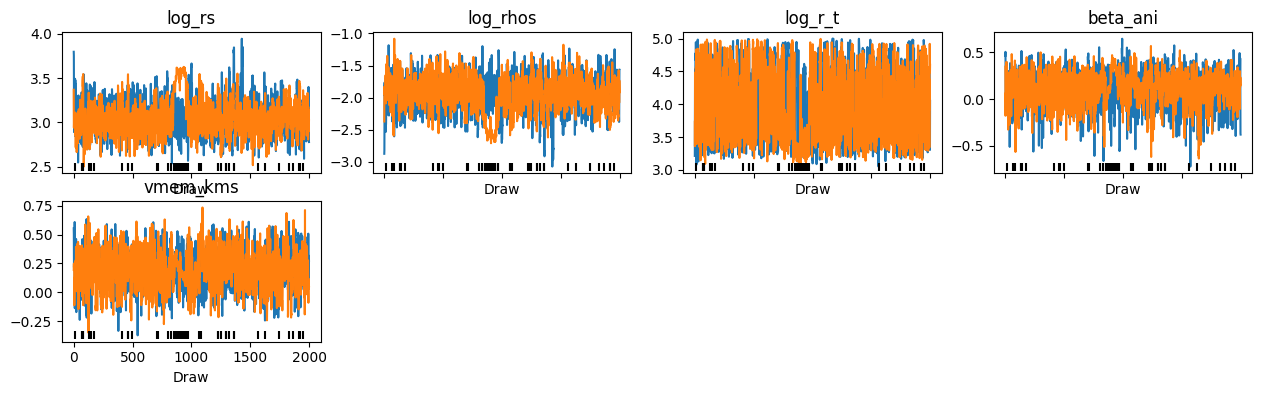

In [17]:
import arviz as az
idata_jeans = az.from_numpyro(mcmc_jeans)
var_names = ["rs_pc", "rhos_Msunpc3", "r_t_pc", "beta_ani", "vmem_kms"]
log_var_names = ["log_rs", "log_rhos", "log_r_t", "beta_ani", "vmem_kms"]
display(az.summary(idata_jeans, var_names=log_var_names))
az.plot_trace(idata_jeans, var_names=log_var_names)
plt.show()

In [18]:
idata_jeans

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                 (chain: 2, draw: 2000)
│       Coordinates:
│         * chain                   (chain) int64 16B 0 1
│         * draw                    (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables:
│           beta_ani                (chain, draw) float32 16kB 0.4622 0.5052 ... 0.1533
│           log10_1_minus_beta_ani  (chain, draw) float32 16kB -0.2694 ... -0.07229
│           log_r_t                 (chain, draw) float32 16kB 3.214 3.774 ... 4.602
│           log_rhos                (chain, draw) float32 16kB -2.873 -2.816 ... -1.914
│           log_rs                  (chain, draw) float32 16kB 3.796 3.756 ... 3.025
│           r_t_pc                  (chain, draw) float32 16kB 1.636e+03 ... 3.999e+04
│           re_pc                   (chain, draw) float32 16kB 200.0 200.0 ... 200.0
│           rhos_Msunpc3            (chain, draw) float32 16kB 0.001339 ... 0.01218
│           rs_pc                   (chain, draw) float32 16kB 6.257e+03 ... 1.059e+03
│           vmem_kms                (chain, draw) float32 16kB 0.5543 0.4967 ... 0.04405
│       Attributes:
│           created_at:                 2026-03-11T06:11:33.187204+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /sample_stats
│       Dimensions:    (chain: 2, draw: 2000)
│       Coordinates:
│         * chain      (chain) int64 16B 0 1
│         * draw       (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           diverging  (chain, draw) bool 4kB ...
│       Attributes:
│           created_at:                 2026-03-11T06:11:33.202896+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /observed_data
        Dimensions:     (vlos_dim_0: 1000)
        Coordinates:
          * vlos_dim_0  (vlos_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
        Data variables:
            vlos        (vlos_dim_0) float32 4kB ...
        Attributes:
            created_at:                 2026-03-11T06:11:33.204030+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

In [19]:
# plot rhat
log_var_names = ["log_rs", "log_rhos", "log_r_t", "beta_ani", "vmem_kms"]
rhat = az.rhat(idata_jeans, var_names=log_var_names)
display(rhat)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:   ()
    Data variables:
        log_rs    float64 8B 1.002
        log_rhos  float64 8B 1.001
        log_r_t   float64 8B 1.004
        beta_ani  float64 8B 1.008
        vmem_kms  float64 8B 1.002

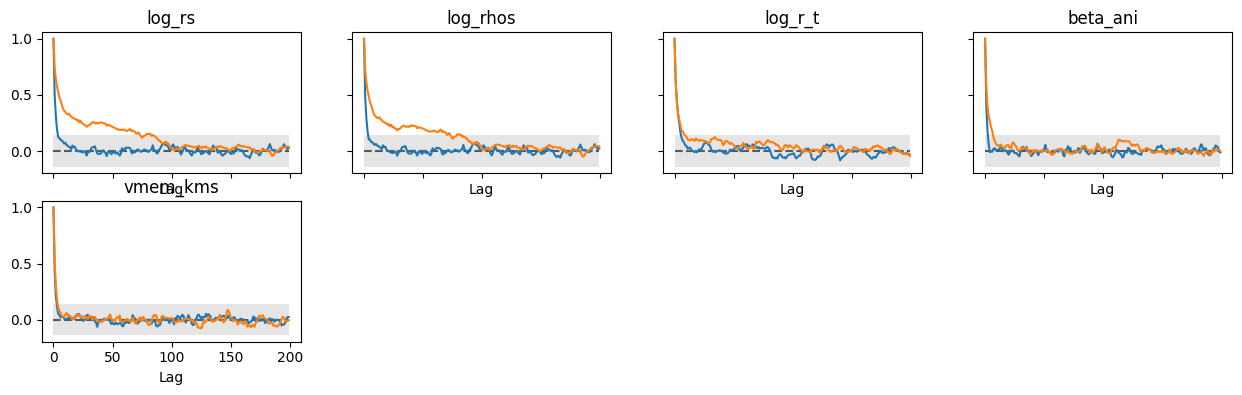

In [20]:
az.plot_autocorr(idata_jeans,var_names=log_var_names,max_lag=200)
plt.show()

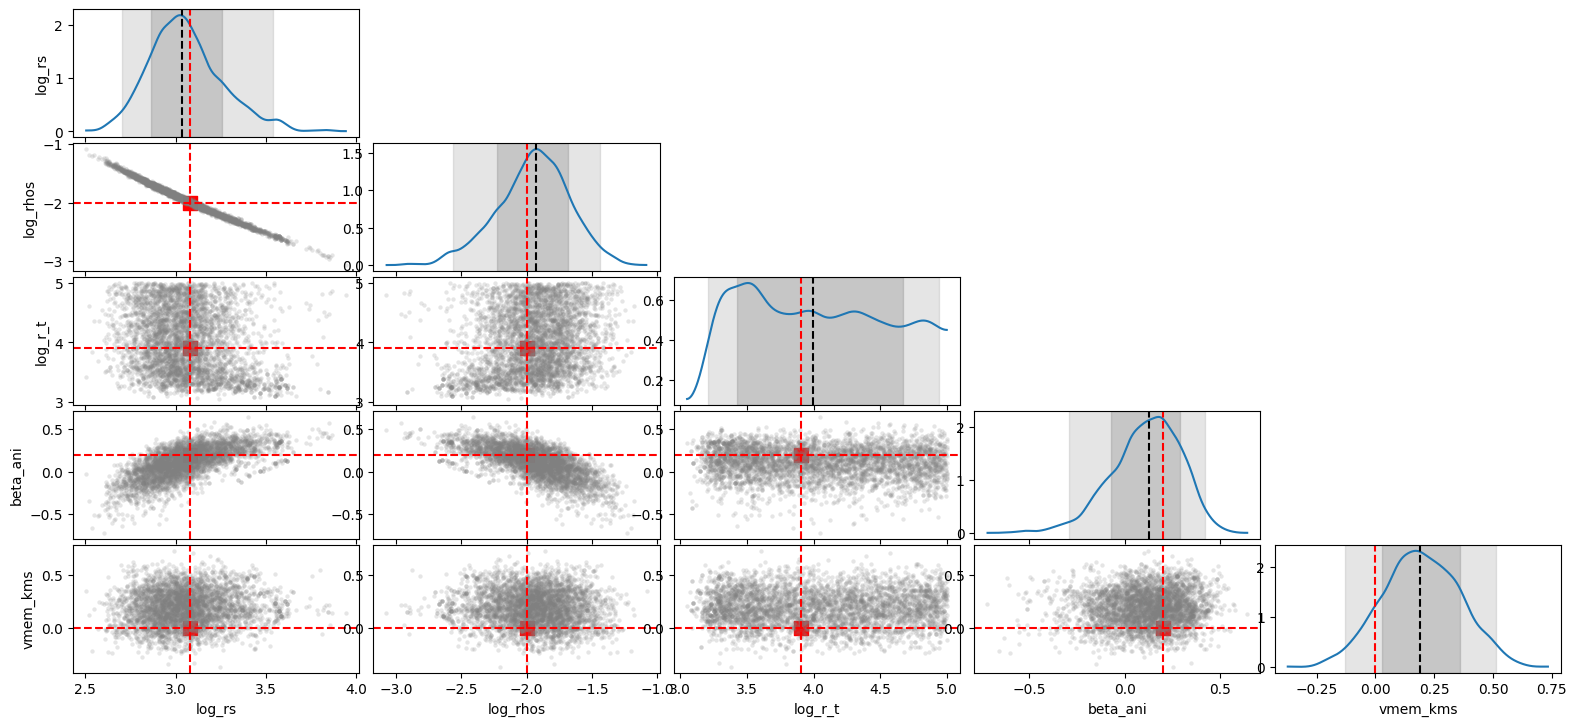

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                 (chain: 2, draw: 2000)
│       Coordinates:
│         * chain                   (chain) int64 16B 0 1
│         * draw                    (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables:
│           beta_ani                (chain, draw) float32 16kB 0.4622 0.5052 ... 0.1533
│           log10_1_minus_beta_ani  (chain, draw) float32 16kB -0.2694 ... -0.07229
│           log_r_t                 (chain, draw) float32 16kB 3.214 3.774 ... 4.602
│           log_rhos                (chain, draw) float32 16kB -2.873 -2.816 ... -1.914
│           log_rs                  (chain, draw) float32 16kB 3.796 3.756 ... 3.025
│           r_t_pc                  (chain, draw) float32 16kB 1.636e+03 ... 3.999e+04
│           re_pc                   (chain, draw) float32 16kB 200.0 200.0 ... 200.0
│           rhos_Msunpc3            (chain, draw) float32 16kB 0.001339 ... 0.01218
│           rs_pc                   (chain, draw) float32 16kB 6.257e+03 ... 1.059e+03
│           vmem_kms                (chain, draw) float32 16kB 0.5543 0.4967 ... 0.04405
│       Attributes:
│           created_at:                 2026-03-11T06:11:33.187204+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /sample_stats
│       Dimensions:    (chain: 2, draw: 2000)
│       Coordinates:
│         * chain      (chain) int64 16B 0 1
│         * draw       (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           diverging  (chain, draw) bool 4kB ...
│       Attributes:
│           created_at:                 2026-03-11T06:11:33.202896+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /observed_data
        Dimensions:     (vlos_dim_0: 1000)
        Coordinates:
          * vlos_dim_0  (vlos_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
        Data variables:
            vlos        (vlos_dim_0) float32 4kB ...
        Attributes:
            created_at:                 2026-03-11T06:11:33.204030+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

In [25]:
# plot likelihood/posterior chains

true_values = {
    "log_rs": jnp.log10(true["rs_pc"]),
    "log_rhos": jnp.log10(true["rhos_Msunpc3"]),
    "log_r_t": jnp.log10(true["r_t_pc"]),
    "beta_ani": true["beta_ani"],
    "vmem_kms": true["vmem_kms"],
}

plot_matrix = az.plot_pair(
    idata_jeans,
    var_names=log_var_names,
    marginal=True,
    marginal_kind="kde",
    triangle="lower",
    backend="matplotlib",
    visuals={
        "scatter": {"color": "gray", "alpha": 0.2, "s": 10},
        "dist": {"color": "C0"},
    },
)

figure = plot_matrix.iget_target(0, 0).figure
figure.subplots_adjust(wspace=0.05, hspace=0.05)

for i, var_i in enumerate(log_var_names):
    true_i = true_values.get(var_i)
    for j, var_j in enumerate(log_var_names):
        if j > i:
            continue

        ax = plot_matrix.iget_target(i, j)
        if i == j:
            if true_i is not None:
                ax.axvline(float(true_i), color="red", linestyle="--", label=f"true {var_i}")

            samples = np.asarray(idata_jeans.posterior[var_i].values).reshape(-1)
            ci_68 = np.percentile(samples, [16, 84])
            ci_95 = np.percentile(samples, [2.5, 97.5])
            ci_50 = float(np.percentile(samples, 50))
            ylim = ax.get_ylim()
            ax.fill_betweenx(y=ylim, x1=ci_68[0], x2=ci_68[1], color="gray", alpha=0.3, label="68% CI")
            ax.fill_betweenx(y=ylim, x1=ci_95[0], x2=ci_95[1], color="gray", alpha=0.2, label="95% CI")
            ax.axvline(ci_50, color="black", linestyle="--", label="median")
            ax.set_ylim(ylim)
            continue

        true_j = true_values.get(var_j)
        if true_i is not None:
            ax.axhline(float(true_i), color="red", linestyle="--")
        if true_j is not None:
            ax.axvline(float(true_j), color="red", linestyle="--")
        if true_i is not None and true_j is not None:
            ax.scatter(float(true_j), float(true_i), color="red", marker="s", s=100)

plt.show()
az.summary(idata_jeans, var_names=log_var_names)
idata_jeans

# Case 2: Plummer + Zhao(Generalized NFW) +constant anisotropy

JAX devices:
1


[CudaDevice(id=0)]

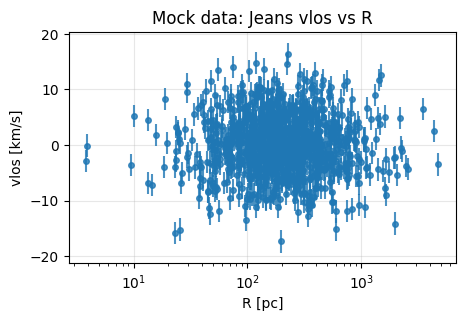

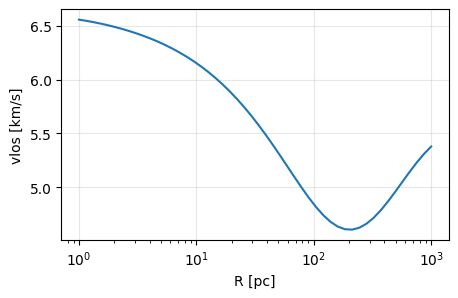

In [22]:
import os
# Tell JAX to avoid the GPU memory allocation in advance but allocate memory as needed
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=2"  # Virtually divide the CPU device into 2 to allow parallel chains on GPU
import numpyro
numpyro.set_host_device_count(2)  # same effect as the above XLA_FLAGS for num_chains=2, but it does not work.... Why?
import jax.random
import jax.numpy as jnp
from numpyro.infer import AIES, MCMC, NUTS
import numpyro.distributions as dist
# Check available JAX devices
print("JAX devices:")
print(jax.local_device_count())
display(jax.devices())
import matplotlib.pyplot as plt
import jeanspy
import jeanspy.model_numpyro
from jeanspy.model_numpyro import ConstantAnisotropyModel, DSphModel, NFWModel, PlummerModel


key = jax.random.PRNGKey(123)

key, subkey = jax.random.split(key)

true = {
    "re_pc": 200.0,
    "rs_pc": 1200.0,
    "rhos_Msunpc3": 1e-2,
    "r_t_pc": 8000.0,
    "beta_ani": 0.2,
    "vmem_kms": 0.0,
}

stellar = PlummerModel()
dm = NFWModel()
ani = ConstantAnisotropyModel()
dsph = DSphModel(submodels={"StellarModel": stellar, "DMModel": dm, "AnisotropyModel": ani})

@jax.jit
def sigmalos2(R_pc, params):
    return dsph.sigmalos2(
        R_pc,
        params=params,
        n_u=192,
        u_max=1500.0,
        constant_kernel_backend="jax",
    )

nR = 1000
R_pc = stellar.sample_R(subkey, nR, re_pc=true["re_pc"])
err = 2.0
err2 = (err * jnp.ones_like(R_pc)) ** 2

s2_true = sigmalos2(R_pc, params=true)
key, subkey = jax.random.split(key)
vlos = true["vmem_kms"] + jnp.sqrt(s2_true + err2) * jax.random.normal(subkey, shape=R_pc.shape)

R_obs = jnp.array(R_pc)
v_obs = jnp.array(vlos)
e_obs = jnp.array(err * jnp.ones_like(R_obs))

# Mock data display
plt.figure(figsize=(5, 3))
plt.errorbar(R_obs, v_obs, yerr=e_obs, fmt="o", ms=4, alpha=0.8)
plt.xscale("log")
plt.title("Mock data: Jeans vlos vs R")
plt.xlabel("R [pc]")
plt.ylabel("vlos [km/s]")
plt.grid(True, alpha=0.3)
plt.show()

# Velocity dispersion proifile (Mock & exact) display
plt.figure(figsize=(5, 3))
_R_obs = jnp.logspace(0,3)
_sig = sigmalos2(_R_obs, params=true)
_sig = jnp.sqrt(_sig)
plt.plot(_R_obs,_sig)
plt.xscale("log")
# plt.ylim(bottom=0)
plt.xlabel("R [pc]")
plt.ylabel("vlos [km/s]")
plt.grid(True, alpha=0.3)
plt.show()

def jeans_model(R_pc, vlos_kms, e_vlos_kms):
    # log_re = numpyro.sample("log_re", dist.Normal(jnp.log(200.0), 0.8))
    log_re = jnp.log10(200)  # deterministic for testing
    log_rs = numpyro.sample("log_rs", dist.Uniform(0.0,5.0))
    log_rhos = numpyro.sample("log_rhos", dist.Uniform(-5.0, 0.0))
    log_r_t = numpyro.sample("log_r_t", dist.Uniform(0.0,5.0))
    beta_ani = numpyro.sample("beta_ani", dist.Uniform(-0.5, 0.8))
    vmem_kms = numpyro.sample("vmem_kms", dist.Uniform(-1000.0, 1000.0))

    re_pc = 10**log_re
    rs_pc = 10**log_rs
    rhos_Msunpc3 = 10**log_rhos
    r_t_pc = 10**log_r_t

    params = {
        "re_pc": re_pc,
        "rs_pc": rs_pc,
        "rhos_Msunpc3": rhos_Msunpc3,
        "r_t_pc": r_t_pc,
        "beta_ani": beta_ani,
        "vmem_kms": vmem_kms,
    }

    s2 = sigmalos2(jnp.asarray(R_pc), params=params)
    s2 = jnp.clip(s2, min=1e-12, max=1e12)
    scale = jnp.sqrt(s2 + jnp.asarray(e_vlos_kms) ** 2)
    numpyro.sample("vlos", dist.Normal(vmem_kms, scale), obs=jnp.asarray(vlos_kms))

    numpyro.deterministic("re_pc", re_pc)
    numpyro.deterministic("rs_pc", rs_pc)
    numpyro.deterministic("rhos_Msunpc3", rhos_Msunpc3)
    numpyro.deterministic("r_t_pc", r_t_pc)
    # numpyro.deterministic("beta_ani", beta_ani)
    # numpyro.deterministic("vmem_kms", vmem_kms)

JAX devices: [CudaDevice(id=0)]


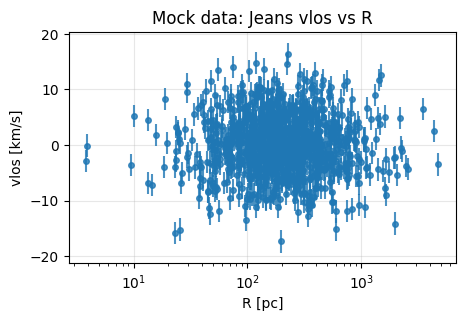

[6.5598445 6.5490537 6.5367894 6.523119  6.508036  6.491483  6.4733686
 6.4535728 6.4319563 6.4083586 6.382603  6.3544955 6.3238273 6.290369
 6.253878  6.2140956 6.1707487 6.1235566 6.072232  6.016491  5.9560637
 5.8907075 5.8202305 5.7445145 5.663548  5.577473  5.4866295 5.391615
 5.2933464 5.1931252 5.092681  4.9942102 4.900354  4.8141346 4.7388
 4.677602  4.6334906 4.6087947 4.6049185 4.6221366 4.65952   4.7150135
 4.785631  4.867725  4.9572687 5.050125  5.1422567 5.2298965 5.3096614
 5.3786297]


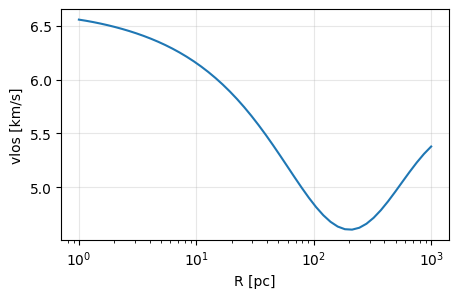

In [23]:
import os
# Tell JAX to avoid the GPU memory allocation in advance but allocate memory as needed
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import numpyro
import jax.random
import jax.numpy as jnp
from numpyro.infer import AIES, MCMC, NUTS
import numpyro.distributions as dist
# Check available JAX devices
print("JAX devices:",jax.devices())
import matplotlib.pyplot as plt
import jeanspy
import jeanspy.model_numpyro
from jeanspy.model_numpyro import ConstantAnisotropyModel, DSphModel, NFWModel, ZhaoModel, PlummerModel

key = jax.random.PRNGKey(123)

key, subkey = jax.random.split(key)

true = {
    "re_pc": 200.0,
    "rs_pc": 1200.0,
    "a": 1.0,
    "b": 3.0,
    "g": 1.0,
    "rhos_Msunpc3": 1e-2,
    "r_t_pc": 8000.0,
    "beta_ani": 0.2,
    "vmem_kms": 0.0,
}

stellar = PlummerModel()
dm = ZhaoModel()
# dm = NFWModel()
ani = ConstantAnisotropyModel()
dsph = DSphModel(submodels={"StellarModel": stellar, "DMModel": dm, "AnisotropyModel": ani})

@jax.jit
def sigmalos2(R_pc, params):
    return dsph.sigmalos2(
        R_pc,
        params=params,
        n_u=192,
        u_max=1500.0,
        use_analytic_dm=False,
        constant_kernel_backend="jax",
    )

nR = 1000
R_pc = stellar.sample_R(subkey, nR, re_pc=true["re_pc"])
err = 2.0
err2 = (err * jnp.ones_like(R_pc)) ** 2

s2_true = sigmalos2(R_pc, params=true)
key, subkey = jax.random.split(key)
vlos = true["vmem_kms"] + jnp.sqrt(s2_true + err2) * jax.random.normal(subkey, shape=R_pc.shape)

R_obs = jnp.array(R_pc)
v_obs = jnp.array(vlos)
e_obs = jnp.array(err * jnp.ones_like(R_obs))

# Mock data display
plt.figure(figsize=(5, 3))
plt.errorbar(R_obs, v_obs, yerr=e_obs, fmt="o", ms=4, alpha=0.8)
plt.xscale("log")
plt.title("Mock data: Jeans vlos vs R")
plt.xlabel("R [pc]")
plt.ylabel("vlos [km/s]")
plt.grid(True, alpha=0.3)
plt.show()

# Velocity dispersion proifile (Mock & exact) display
plt.figure(figsize=(5, 3))
_R_obs = jnp.logspace(0,3)
_sig = sigmalos2(_R_obs, params=true)
_sig = jnp.sqrt(_sig)
print(_sig  )
plt.plot(_R_obs,_sig)
plt.xscale("log")
# plt.ylim(bottom=0)
plt.xlabel("R [pc]")
plt.ylabel("vlos [km/s]")
plt.grid(True, alpha=0.3)
plt.show()

def jeans_model(R_pc, vlos_kms, e_vlos_kms):
    # log_re = numpyro.sample("log_re", dist.Normal(jnp.log(200.0), 0.8))
    log_re = jnp.log(200)  # deterministic for testing
    log_rs = numpyro.sample("log_rs", dist.Uniform(0.0,5.0))
    log_rhos = numpyro.sample("log_rhos", dist.Uniform(-5.0, 0.0))
    a = numpyro.sample("a", dist.Uniform(0.5, 1.5))
    b = numpyro.sample("b", dist.Uniform(2.0, 4.0))
    g = numpyro.sample("g", dist.Uniform(0.0, 1.5))
    log_r_t = numpyro.sample("log_r_t", dist.Uniform(0.0,5.0))
    beta_ani = numpyro.sample("beta_ani", dist.Uniform(-0.5, 0.8))
    vmem_kms = numpyro.sample("vmem_kms", dist.Uniform(-1000.0, 1000.0))

    re_pc = jnp.exp(log_re)
    rs_pc = jnp.exp(log_rs)
    rhos_Msunpc3 = jnp.exp(log_rhos)
    r_t_pc = jnp.exp(log_r_t)

    params = {
        "re_pc": re_pc,
        "rs_pc": rs_pc,
        "rhos_Msunpc3": rhos_Msunpc3,
        "a": a,
        "b": b,
        "g": g,
        "r_t_pc": r_t_pc,
        "beta_ani": beta_ani,
        "vmem_kms": vmem_kms,
    }

    s2 = sigmalos2(jnp.asarray(R_pc), params=params)
    s2 = jnp.clip(s2, min=1e-12, max=1e12)
    scale = jnp.sqrt(s2 + jnp.asarray(e_vlos_kms) ** 2)
    numpyro.sample("vlos", dist.Normal(vmem_kms, scale), obs=jnp.asarray(vlos_kms))

    numpyro.deterministic("re_pc", re_pc)
    numpyro.deterministic("rs_pc", rs_pc)
    numpyro.deterministic("rhos_Msunpc3", rhos_Msunpc3)
    numpyro.deterministic("r_t_pc", r_t_pc)
    # numpyro.deterministic("beta_ani", beta_ani)
    # numpyro.deterministic("vmem_kms", vmem_kms)

In [24]:
import arviz as az
import time

num_chains = 2
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_chains)

sampler = NUTS(
    jeans_model,
    dense_mass=True,
    max_tree_depth=5,
    target_accept_prob=0.8,
)
mcmc_jeans_plummer_zhao = MCMC(
    sampler,
    num_warmup=400,
    num_samples=2000,
    num_chains=num_chains,
    chain_method="parallel",
    progress_bar=True,
    jit_model_args=True,
)
mcmc_jeans_plummer_zhao.run(keys, R_pc=R_obs, vlos_kms=v_obs, e_vlos_kms=e_obs)

idata_jeans_plummer_zhao = az.from_numpyro(mcmc_jeans_plummer_zhao)
timestamp = int(time.time())
idata_jeans_plummer_zhao.to_netcdf(f"jeans_plummer_zhao_nuts_{timestamp}.nc")
display(idata_jeans_plummer_zhao)
diverging = idata_jeans_plummer_zhao.sample_stats["diverging"]
print("divergences:", diverging.sum().values, "/", diverging.size)
var_names = ["log_rs", "log_rhos", "a", "b", "g", "log_r_t", "beta_ani", "vmem_kms"]
display(az.summary(idata_jeans_plummer_zhao, var_names=var_names))
az.plot_trace(idata_jeans_plummer_zhao, var_names=var_names)
plt.show()

/tmp/ipykernel_428618/1775925939.py:14: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_jeans_plummer_zhao = MCMC(
warmup:   2%|▏         | 52/2400 [00:13<09:29,  4.12it/s, 31 steps of size 8.12e-05. acc. prob=0.70]

warmup:  15%|█▌        | 364/2400 [01:21<07:38,  4.44it/s, 31 steps of size 2.04e-02. acc. prob=0.78]


KeyboardInterrupt: 

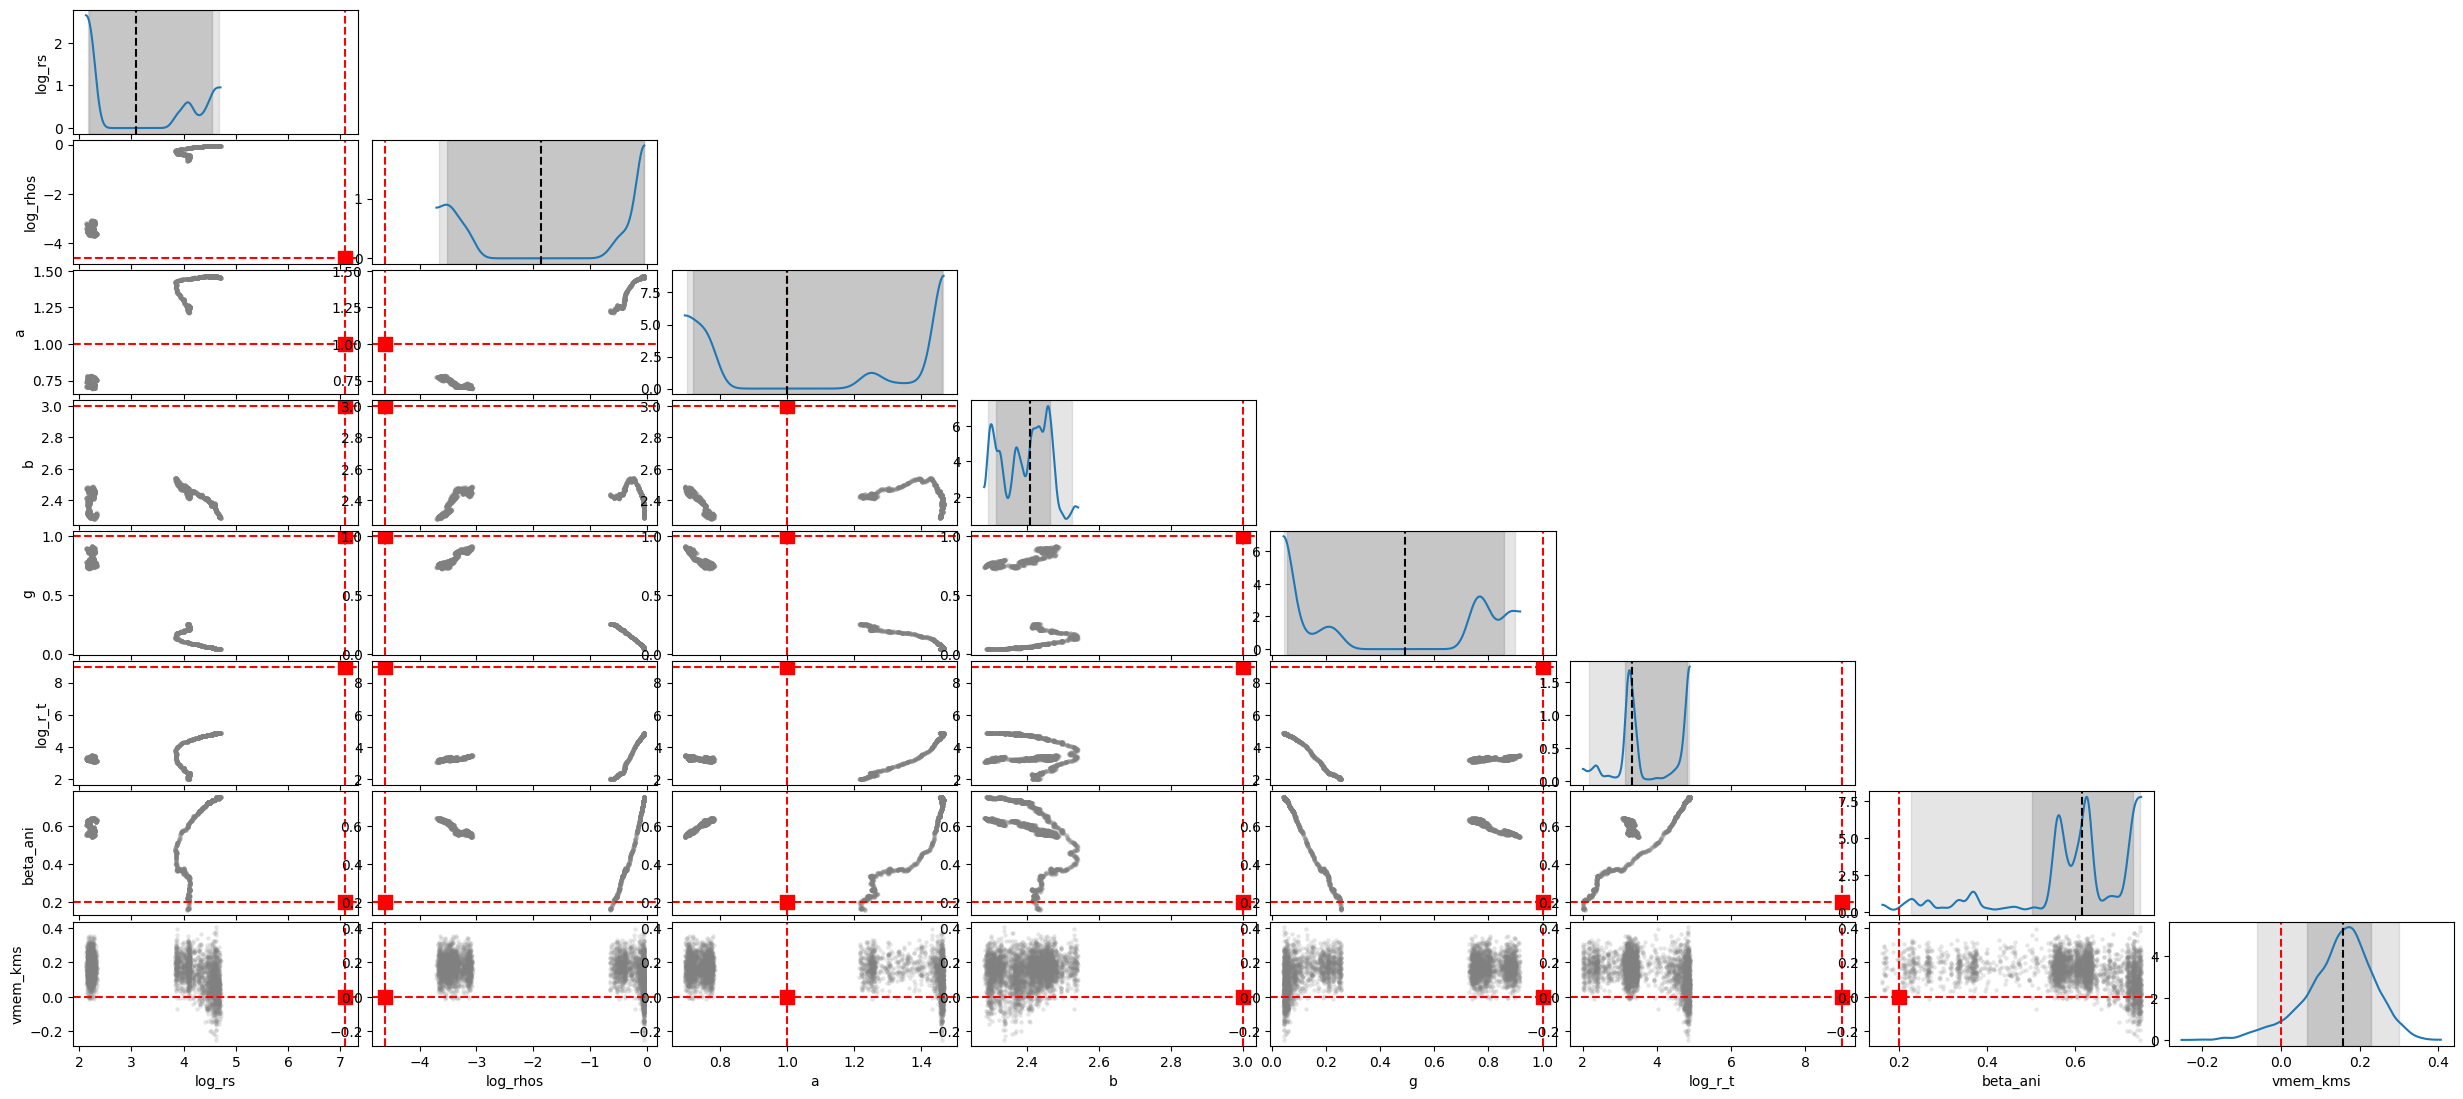

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:       (chain: 2, draw: 2000)
│       Coordinates:
│         * chain         (chain) int64 16B 0 1
│         * draw          (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
│       Data variables:
│           a             (chain, draw) float32 16kB 0.751 0.7522 0.7511 ... 1.455 1.455
│           b             (chain, draw) float32 16kB 2.321 2.319 2.318 ... 2.289 2.289
│           beta_ani      (chain, draw) float32 16kB 0.628 0.6282 ... 0.7491 0.7492
│           g             (chain, draw) float32 16kB 0.7513 0.7494 ... 0.04732 0.04729
│           log_r_t       (chain, draw) float32 16kB 3.156 3.154 3.147 ... 4.876 4.875
│           log_rhos      (chain, draw) float32 16kB -3.602 -3.607 ... -0.03984 -0.03985
│           log_rs        (chain, draw) float32 16kB 2.328 2.333 2.331 ... 4.704 4.704
│           r_t_pc        (chain, draw) float32 16kB 23.49 23.43 23.26 ... 131.1 131.0
│           re_pc         (chain, draw) float32 16kB 200.0 200.0 200.0 ... 200.0 200.0
│           rhos_Msunpc3  (chain, draw) float32 16kB 0.02726 0.02714 ... 0.9609 0.9609
│           rs_pc         (chain, draw) float32 16kB 10.26 10.31 10.29 ... 110.4 110.4
│           vmem_kms      (chain, draw) float32 16kB 0.1627 0.1694 ... 0.207 0.02203
│       Attributes:
│           created_at:                 2026-03-11T04:47:39.082991+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /sample_stats
│       Dimensions:    (chain: 2, draw: 2000)
│       Coordinates:
│         * chain      (chain) int64 16B 0 1
│         * draw       (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           diverging  (chain, draw) bool 4kB ...
│       Attributes:
│           created_at:                 2026-03-11T04:47:39.095243+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /observed_data
        Dimensions:     (vlos_dim_0: 1000)
        Coordinates:
          * vlos_dim_0  (vlos_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
        Data variables:
            vlos        (vlos_dim_0) float32 4kB ...
        Attributes:
            created_at:                 2026-03-11T04:47:39.096301+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

In [ ]:
# plot likelihood/posterior chains

log_var_names = ["log_rs", "log_rhos", "a", "b", "g", "log_r_t", "beta_ani", "vmem_kms"]



true_values = {

    "log_rs": jnp.log(true["rs_pc"]),

    "log_rhos": jnp.log(true["rhos_Msunpc3"]),

    "a": true["a"],

    "b": true["b"],

    "g": true["g"],

    "log_r_t": jnp.log(true["r_t_pc"]),

    "beta_ani": true["beta_ani"],

    "vmem_kms": true["vmem_kms"],

}



previous_max_subplots = az.rcParams["plot.max_subplots"]

az.rcParams["plot.max_subplots"] = 80

try:

    plot_matrix = az.plot_pair(

        idata_jeans_plummer_zhao,

        var_names=log_var_names,

        marginal=True,

        marginal_kind="kde",

        triangle="lower",

        backend="matplotlib",

        visuals={

            "scatter": {"color": "gray", "alpha": 0.2, "s": 10},

            "dist": {"color": "C0"},

        },

    )

finally:

    az.rcParams["plot.max_subplots"] = previous_max_subplots



figure = plot_matrix.iget_target(0, 0).figure

figure.subplots_adjust(wspace=0.05, hspace=0.05)



for i, var_i in enumerate(log_var_names):

    true_i = true_values.get(var_i)

    for j, var_j in enumerate(log_var_names):

        if j > i:

            continue



        ax = plot_matrix.iget_target(i, j)

        if i == j:

            if true_i is not None:

                ax.axvline(float(true_i), color="red", linestyle="--", label=f"true {var_i}")



            samples = np.asarray(idata_jeans_plummer_zhao.posterior[var_i].values).reshape(-1)

            ci_68 = np.percentile(samples, [16, 84])

            ci_95 = np.percentile(samples, [2.5, 97.5])

            ci_50 = float(np.percentile(samples, 50))

            ylim = ax.get_ylim()

            ax.fill_betweenx(y=ylim, x1=ci_68[0], x2=ci_68[1], color="gray", alpha=0.3, label="68% CI")

            ax.fill_betweenx(y=ylim, x1=ci_95[0], x2=ci_95[1], color="gray", alpha=0.2, label="95% CI")

            ax.axvline(ci_50, color="black", linestyle="--", label="median")

            ax.set_ylim(ylim)

            continue



        true_j = true_values.get(var_j)

        if true_i is not None:

            ax.axhline(float(true_i), color="red", linestyle="--")

        if true_j is not None:

            ax.axvline(float(true_j), color="red", linestyle="--")

        if true_i is not None and true_j is not None:

            ax.scatter(float(true_j), float(true_i), color="red", marker="s", s=100)



plt.show()

az.summary(idata_jeans_plummer_zhao, var_names=log_var_names)

idata_jeans_plummer_zhao


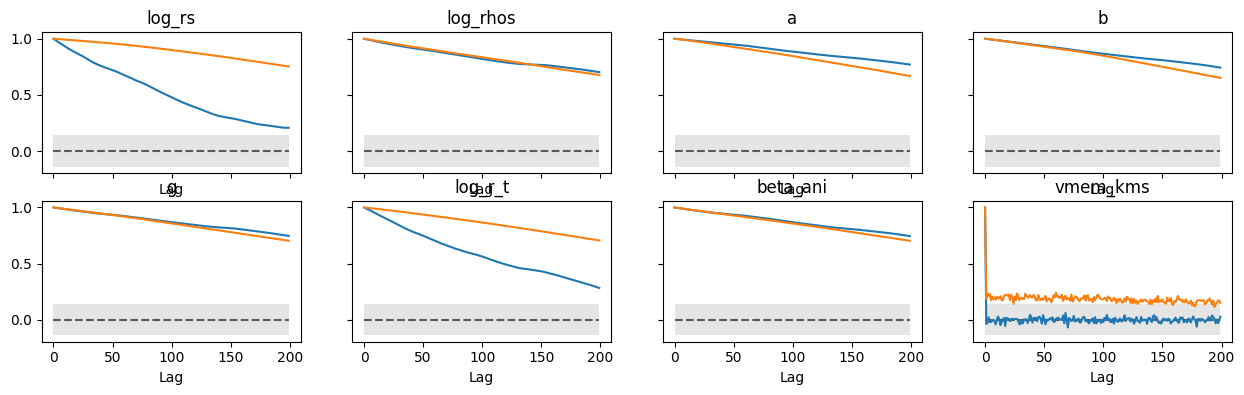

In [ ]:
az.plot_autocorr(idata_jeans_plummer_zhao,var_names=log_var_names,max_lag=200)

# Appendix

## Hypergeometric function comparison

scipy hyp2f1 matches mpmath exactly in this test


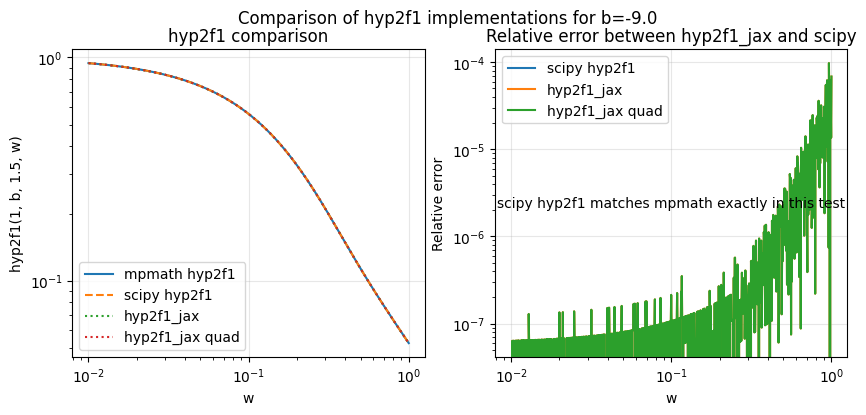

scipy hyp2f1 matches mpmath exactly in this test


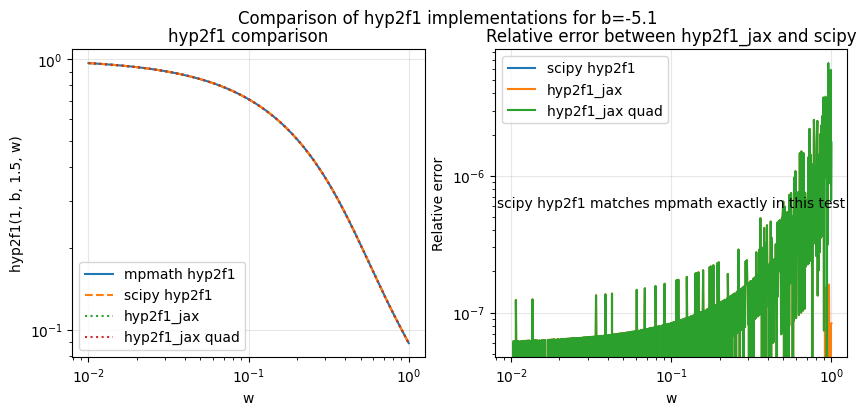

scipy hyp2f1 matches mpmath exactly in this test
hyp2f1_jax matches mpmath exactly in this test
hyp2f1_jax quad matches mpmath exactly in this test


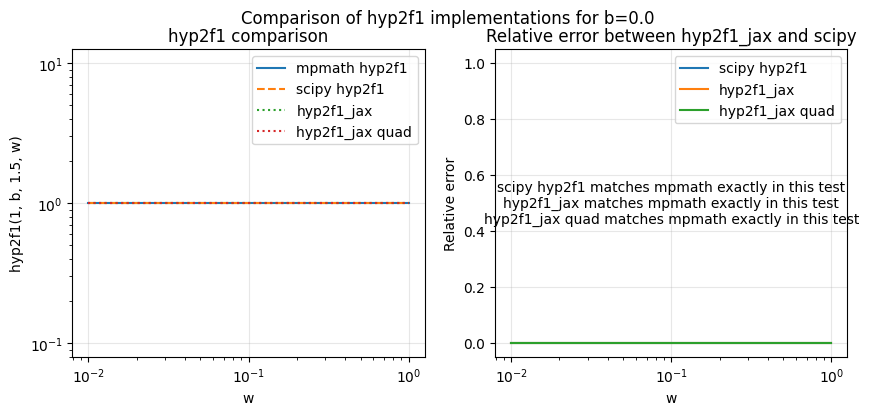

scipy hyp2f1 matches mpmath exactly in this test


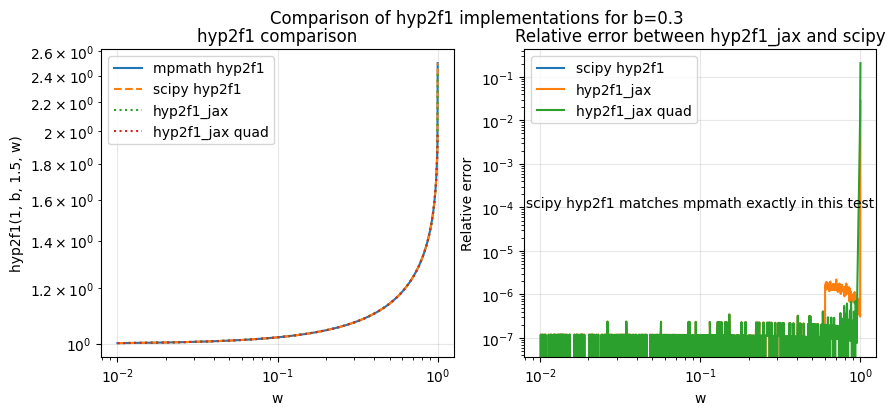

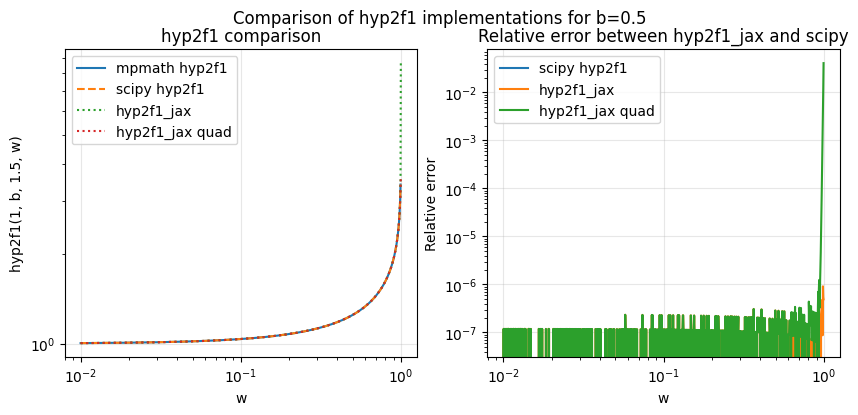

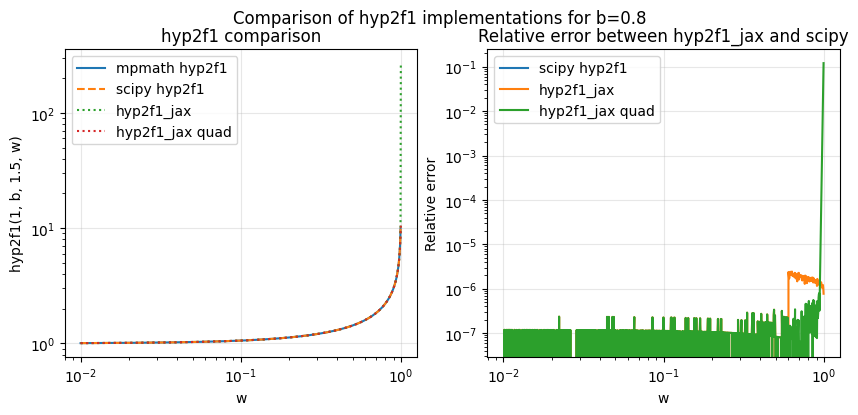

In [ ]:
import jeanspy.hyp2f1_jax as hyp2f1_jax

import jax.numpy as jnp

from scipy.special import hyp2f1

import matplotlib.pyplot as plt

import mpmath

from mpmath import hyp2f1 as hyp2f1_mpmath

mpmath.mp.dps = 100  # set decimal places for mpmath



for b in [-9, -5.1, 0, 0.3, 0.5, 0.8]:

    w = jnp.logspace(-2, 0, 1024)

    b = jnp.broadcast_to(b, w.shape)



    y0 = [float(hyp2f1_mpmath(1.0, float(_b), 1.5, float(_w))) for _b, _w in zip(b, w)]

    y0 = jnp.array(y0)

    y1 = hyp2f1(1.0, b, 1.5, w)

    y2 = hyp2f1_jax.hyp2f1_1b_3half(b=b, w=w)

    y21 = hyp2f1_jax.hyp2f1_1b_3half(b=b, w=w, method="series")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))



    axes[0].plot(w, y0, label="mpmath hyp2f1")

    axes[0].plot(w, y1, label="scipy hyp2f1", linestyle="--")

    axes[0].plot(w, y2, label="hyp2f1_jax", linestyle=":")

    axes[0].plot(w, y21, label="hyp2f1_jax quad", linestyle=":")

    axes[0].set_xscale("log")

    axes[0].set_yscale("log")

    axes[0].legend()

    axes[0].set_title("hyp2f1 comparison")

    axes[0].set_xlabel("w")

    axes[0].set_ylabel("hyp2f1(1, b, 1.5, w)")

    axes[0].grid(True, alpha=0.3)



    rel_error_1 = jnp.abs(y1 - y0) / jnp.abs(y0)

    rel_error_2 = jnp.abs(y2 - y0) / jnp.abs(y0)

    rel_error_21 = jnp.abs(y21 - y0) / jnp.abs(y0)

    axes[1].plot(w, rel_error_1, label="scipy hyp2f1")

    axes[1].plot(w, rel_error_2, label="hyp2f1_jax")

    axes[1].plot(w, rel_error_21, label="hyp2f1_jax quad")



    exact_messages = []

    if jnp.all(rel_error_1 == 0):

        exact_messages.append("scipy hyp2f1 matches mpmath exactly in this test")

    if jnp.all(rel_error_2 == 0):

        exact_messages.append("hyp2f1_jax matches mpmath exactly in this test")

    if jnp.all(rel_error_21 == 0):

        exact_messages.append("hyp2f1_jax quad matches mpmath exactly in this test")



    positive_rel_error = (rel_error_1 > 0).any() or (rel_error_2 > 0).any() or (rel_error_21 > 0).any()

    axes[1].set_xscale("log")

    if positive_rel_error:

        axes[1].set_yscale("log")

    else:

        axes[1].set_ylim(-0.05, 1.05)



    if exact_messages:

        for message in exact_messages:

            print(message)

        axes[1].text(

            0.5,

            0.5,

            "\n".join(exact_messages),

            transform=axes[1].transAxes,

            ha="center",

            va="center",

        )



    axes[1].legend()

    axes[1].set_title("Relative error between hyp2f1_jax and scipy")

    axes[1].set_xlabel("w")

    axes[1].set_ylabel("Relative error")

    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"Comparison of hyp2f1 implementations for b={b[0]:.1f}")

    plt.show()
